# Forcing Extremes
## Goal: Visually observe underfitting and overfitting.
#### Task: Generate a non-linear regression dataset using make_regression or mathematical functions (like a noisy sine wave).
#### Deliverable: Train three DecisionTreeRegressor models: one with max_depth=1 (high bias), one with max_depth=3 (balanced), and one with max_depth=None (high variance). Plot the true data alongside the prediction lines of all three models on the same graph using Matplotlib or Seaborn.

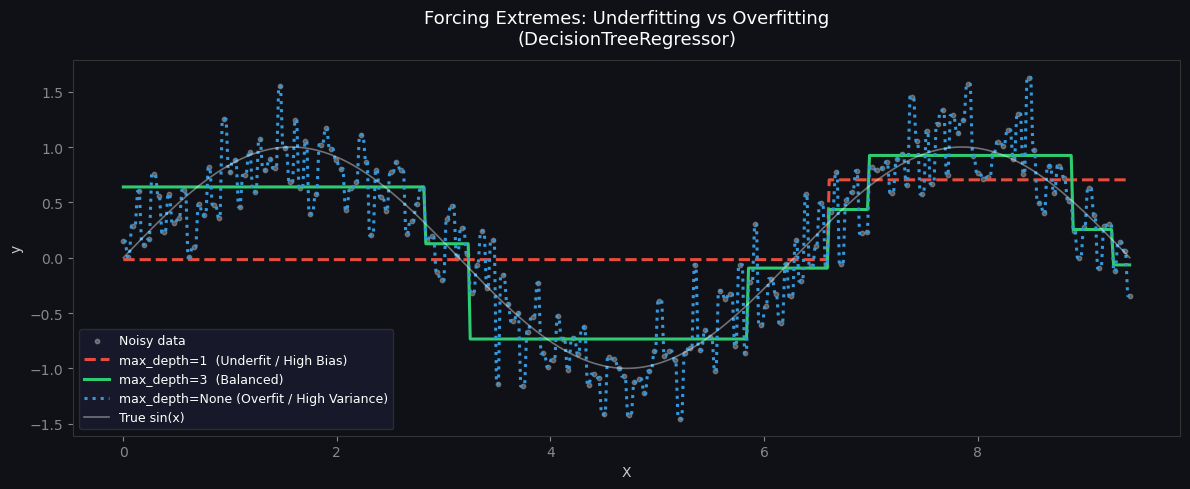

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# --- Data ---
np.random.seed(42)
X = np.linspace(0, 3 * np.pi, 200).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.3, X.shape[0])

X_plot = np.linspace(0, 3 * np.pi, 500).reshape(-1, 1)

# --- Models ---
models = {
    "max_depth=1  (Underfit / High Bias)": DecisionTreeRegressor(max_depth=1),
    "max_depth=3  (Balanced)":             DecisionTreeRegressor(max_depth=3),
    "max_depth=None (Overfit / High Variance)": DecisionTreeRegressor(max_depth=None),
}

colors = ["#e74c3c", "#2ecc71", "#3498db"]
styles = ["--", "-", ":"]

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#0f1117")

ax.scatter(X, y, color="#aaaaaa", s=10, alpha=0.5, label="Noisy data", zorder=1)

for (label, model), color, ls in zip(models.items(), colors, styles):
    model.fit(X, y)
    y_pred = model.predict(X_plot)
    ax.plot(X_plot, y_pred, color=color, linewidth=2.2, linestyle=ls, label=label, zorder=2)

# True function
ax.plot(X_plot, np.sin(X_plot), color="white", linewidth=1.2,
        alpha=0.4, linestyle="-", label="True sin(x)", zorder=3)

# Style
ax.set_title("Forcing Extremes: Underfitting vs Overfitting\n(DecisionTreeRegressor)",
             color="white", fontsize=13, pad=12)
ax.set_xlabel("X", color="#cccccc")
ax.set_ylabel("y", color="#cccccc")
ax.tick_params(colors="#888888")
for spine in ax.spines.values():
    spine.set_edgecolor("#333333")

legend = ax.legend(facecolor="#1a1a2e", edgecolor="#333333", labelcolor="white", fontsize=9)
plt.tight_layout()
plt.show()